# LightGBM Robustness Experiment

This notebook evaluates LightGBM using Colour, LBP, HOG, and Spatial features.

## Experimental setup

- Dataset: 17,028 labelled images from six scene classes.
- Conditions: clean images, three Gaussian blur levels, and three brightness reduction levels.
- Evaluation: 10 outer folds and 3 inner folds, using the same saved splits as Logistic Regression and MLP.
- Hyperparameter selection: select num_leaves using mean inner-fold Macro-F1.
- Training and tuning use clean images only. Each fitted model is evaluated on the same held-out image indices under all seven conditions.
- Final results report the mean and sample standard deviation across the ten outer folds.

## Final candidate ranges

| Feature | num_leaves candidates |
|---|---|
| Colour | 31, 127, 511 |
| LBP | 15, 31, 63 |
| HOG | 31, 63, 127 |
| Spatial | 15, 31, 63 |

Earlier pilot sections record how the candidate ranges were refined. The final reported results are saved in:
- results/lightgbm/lightgbm_results.csv
- results/lightgbm/lightgbm_inner_tuning.csv

Cross-validation loops, hyperparameter selection, and classification metrics are implemented explicitly. Model fitting uses the LightGBM library.

In [1]:
import csv
import gc
import pickle
from pathlib import Path

import numpy as np
from lightgbm import LGBMClassifier

# Shared data and output locations.
FEATURE_DIR = Path("features")
RESULT_DIR = Path("results")
MODEL_RESULT_DIR = RESULT_DIR / "lightgbm"
FOLD_FILE = RESULT_DIR / "outer_and_inner_folds.pkl"

FEATURE_KEYS = ["colour", "hog", "lbp", "spatial"]
CONDITION_ORDER = [
    "clean",
    "blur_mild", "blur_medium", "blur_severe",
    "brightness_mild", "brightness_medium", "brightness_severe",
]

# Check that all seven feature files are available.
for condition in CONDITION_ORDER:
    path = FEATURE_DIR / f"{condition}.npz"
    assert path.is_file(), f"Missing file: {path}"

# Read the reference labels and image indices.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as data:
    Y = data["labels"]
    REFERENCE_INDICES = data["indices"]

# Reuse the exact outer and inner splits used by the other models.
with FOLD_FILE.open("rb") as f:
    fold_data = pickle.load(f)

OUTER_FOLDS = fold_data["outer_folds"]
INNER_FOLDS_BY_OUTER = fold_data["inner_folds_by_outer"]

assert fold_data["outer_k"] == 10
assert fold_data["inner_k"] == 3
assert len(OUTER_FOLDS) == 10
assert np.array_equal(REFERENCE_INDICES, np.arange(len(Y)))

print("Samples:", len(Y))
print("Conditions:", len(CONDITION_ORDER))
print("Outer folds:", len(OUTER_FOLDS))
print("Inner folds:", fold_data["inner_k"])

Samples: 17028
Conditions: 7
Outer folds: 10
Inner folds: 3


In [2]:
# Calculate classification metrics manually.
def classification_metrics(y_true, y_pred, n_classes=6):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    for actual, predicted in zip(y_true, y_pred):
        confusion[actual, predicted] += 1

    total = confusion.sum()
    accuracy = float(np.trace(confusion) / total) if total else 0.0

    precision_values = []
    recall_values = []
    f1_values = []

    for class_id in range(n_classes):
        tp = confusion[class_id, class_id]
        fp = confusion[:, class_id].sum() - tp
        fn = confusion[class_id, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) else 0.0
        )

        precision_values.append(precision)
        recall_values.append(recall)
        f1_values.append(f1)

    return {
        "accuracy": accuracy,
        "macro_precision": float(np.mean(precision_values)),
        "macro_recall": float(np.mean(recall_values)),
        "macro_f1": float(np.mean(f1_values)),
        "confusion_matrix": confusion,
    }


# Train a fresh LightGBM model for the current split.
def fit_lightgbm(X_train, y_train, leaves):
    model = LGBMClassifier(
        objective="multiclass",
        num_leaves=int(leaves),
        learning_rate=0.05,
        n_estimators=200,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(X_train, y_train)
    return model


print("Metric and LightGBM functions ready.")

Metric and LightGBM functions ready.


In [6]:
# Tune num_leaves using the saved inner folds.
def tune_lightgbm(X_clean, feature_key, outer_fold, candidates):
    fold_id = int(outer_fold["fold_id"])
    train_idx = np.asarray(outer_fold["train_indices"], dtype=np.int64)
    inner_folds = INNER_FOLDS_BY_OUTER[fold_id]

    mean_scores = {}
    tuning_rows = []

    for leaves in sorted(candidates):
        scores = []

        for inner_id, validation_idx in enumerate(inner_folds):
            validation_idx = np.asarray(validation_idx, dtype=np.int64)
            fit_idx = np.setdiff1d(
                train_idx, validation_idx, assume_unique=True
            )

            model = fit_lightgbm(
                X_clean[fit_idx], Y[fit_idx], leaves
            )
            predictions = model.predict(X_clean[validation_idx])
            metrics = classification_metrics(Y[validation_idx], predictions)

            scores.append(metrics["macro_f1"])
            tuning_rows.append({
                "model": "lightgbm",
                "feature_representation": feature_key,
                "outer_fold": fold_id,
                "inner_fold": inner_id,
                "num_leaves": int(leaves),
                "macro_f1": metrics["macro_f1"],
                "n_train": len(fit_idx),
                "n_validation": len(validation_idx),
                "n_iter": model.n_iter_,
            })

            print(
                f"leaves={leaves}, inner fold={inner_id + 1}: "
                f"Macro-F1={metrics['macro_f1']:.4f}",
                flush=True,
            )

        mean_scores[leaves] = float(np.mean(scores))
        print(
            f"Mean Macro-F1: {mean_scores[leaves]:.4f}\n",
            flush=True,
        )

    # Prefer the smaller candidate if mean scores tie.
    best_leaves = max(
        mean_scores,
        key=lambda leaves: (mean_scores[leaves], -leaves),
    )
    return best_leaves, mean_scores, tuning_rows

print("Tuning function ready.")


Tuning function ready.


In [3]:
# Load only clean Colour features for this pilot.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as data:
    X_colour = data["colour"]

colour_best, colour_scores, colour_pilot_tuning = tune_lightgbm(
    X_colour,
    "colour",
    OUTER_FOLDS[0],
    candidates=[63, 127, 255],
)

print("Selected num_leaves:", colour_best)


leaves=63, inner fold=1: Macro-F1=0.5961
leaves=63, inner fold=2: Macro-F1=0.6068
leaves=63, inner fold=3: Macro-F1=0.6051
Mean Macro-F1: 0.6027

leaves=127, inner fold=1: Macro-F1=0.5927
leaves=127, inner fold=2: Macro-F1=0.6038
leaves=127, inner fold=3: Macro-F1=0.6078
Mean Macro-F1: 0.6014

leaves=255, inner fold=1: Macro-F1=0.5975
leaves=255, inner fold=2: Macro-F1=0.6009
leaves=255, inner fold=3: Macro-F1=0.6124
Mean Macro-F1: 0.6036

Selected num_leaves: 255


In [4]:
# Refit on the outer training set and evaluate all seven conditions.
def evaluate_outer_fold(feature_key, X_clean, outer_fold, leaves):
    fold_id = int(outer_fold["fold_id"])
    train_idx = np.asarray(outer_fold["train_indices"], dtype=np.int64)
    test_idx = np.asarray(outer_fold["test_indices"], dtype=np.int64)

    model = fit_lightgbm(X_clean[train_idx], Y[train_idx], leaves)
    result_rows = []
    saved_predictions = {
        "image_indices": test_idx,
        "labels": Y[test_idx],
    }

    for condition in CONDITION_ORDER:
        path = FEATURE_DIR / f"{condition}.npz"

        with np.load(path, allow_pickle=False) as data:
            # Confirm that the condition uses the same image ordering.
            assert np.array_equal(data["labels"], Y)
            assert np.array_equal(data["indices"], REFERENCE_INDICES)
            X_test = data[feature_key][test_idx]

        predictions = model.predict(X_test)
        metrics = classification_metrics(Y[test_idx], predictions)

        result_rows.append({
            "model": "lightgbm",
            "feature_representation": feature_key,
            "outer_fold": fold_id,
            "condition": condition,
            "num_leaves": int(leaves),
            "accuracy": metrics["accuracy"],
            "macro_precision": metrics["macro_precision"],
            "macro_recall": metrics["macro_recall"],
            "macro_f1": metrics["macro_f1"],
            "n_test": len(test_idx),
            "correct_predictions": int(np.sum(predictions == Y[test_idx])),
            "n_iter": model.n_iter_,
        })

        saved_predictions[condition] = predictions
        saved_predictions[f"{condition}_cm"] = metrics["confusion_matrix"]

        print(
            f"{condition:<19} "
            f"Accuracy={metrics['accuracy']:.2%}  "
            f"Macro-F1={metrics['macro_f1']:.4f}",
            flush=True,
        )

    return result_rows, saved_predictions


colour_first_results, colour_first_predictions = evaluate_outer_fold(
    "colour", X_colour, OUTER_FOLDS[0], colour_best
)

# Preserve this completed fold so it can be reused later.
checkpoint_dir = MODEL_RESULT_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

colour_first_checkpoint = {
    "feature_representation": "colour",
    "outer_fold": 0,
    "candidates": [63, 127, 255],
    "num_leaves": int(colour_best),
    "results": colour_first_results,
    "tuning": [
        {key: value for key, value in row.items()
         if key != "elapsed_seconds"}
        for row in colour_pilot_tuning
    ],
    "predictions": colour_first_predictions,
}

with (checkpoint_dir / "colour_fold_1.pkl").open("wb") as f:
    pickle.dump(colour_first_checkpoint, f)

print("Saved Colour fold 1 checkpoint.")

clean               Accuracy=61.66%  Macro-F1=0.6115
blur_mild           Accuracy=44.84%  Macro-F1=0.4203
blur_medium         Accuracy=38.45%  Macro-F1=0.3408
blur_severe         Accuracy=36.87%  Macro-F1=0.3190
brightness_mild     Accuracy=40.80%  Macro-F1=0.3305
brightness_medium   Accuracy=37.28%  Macro-F1=0.2800
brightness_severe   Accuracy=26.32%  Macro-F1=0.1650
Saved Colour fold 1 checkpoint.


In [5]:
# Record the inputs and model settings used by this run.
source_paths = [FOLD_FILE] + [
    FEATURE_DIR / f"{condition}.npz"
    for condition in CONDITION_ORDER
]
source_signature = {
    str(path): (path.stat().st_size, path.stat().st_mtime_ns)
    for path in source_paths
}

MODEL_PARAMS = {
    "objective": "multiclass",
    "learning_rate": 0.05,
    "n_estimators": 200,
    "random_state": 42,
    "n_jobs": 4,
    "verbosity": -1,
}


def fit_lightgbm(X_train, y_train, leaves):
    model = LGBMClassifier(num_leaves=int(leaves), **MODEL_PARAMS)
    model.fit(X_train, y_train)
    return model


def checkpoint_config(feature_key, candidates):
    return {
        "feature_representation": feature_key,
        "candidates": sorted(candidates),
        "model_params": MODEL_PARAMS.copy(),
        "source_signature": source_signature.copy(),
    }


def write_csv(path, rows):
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


# Add configuration metadata to the first fold just completed.
first_path = checkpoint_dir / "colour_fold_1.pkl"
with first_path.open("rb") as f:
    first_checkpoint = pickle.load(f)

if "config" not in first_checkpoint:
    assert first_checkpoint["candidates"] == [63, 127, 255]
    assert np.array_equal(
        first_checkpoint["predictions"]["image_indices"],
        OUTER_FOLDS[0]["test_indices"],
    )
    first_checkpoint["config"] = checkpoint_config(
        "colour", [63, 127, 255]
    )
    with first_path.open("wb") as f:
        pickle.dump(first_checkpoint, f)


# Run or resume all ten outer folds for one feature representation.
def run_shared_cv(feature_key, candidates):
    feature_result_dir = MODEL_RESULT_DIR / feature_key
    feature_result_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as data:
        assert np.array_equal(data["labels"], Y)
        assert np.array_equal(data["indices"], REFERENCE_INDICES)
        X_clean = data[feature_key]

    result_rows = []
    tuning_rows = []
    config = checkpoint_config(feature_key, candidates)

    for outer_fold in OUTER_FOLDS:
        fold_id = int(outer_fold["fold_id"])
        path = checkpoint_dir / f"{feature_key}_fold_{fold_id + 1}.pkl"

        if path.exists():
            with path.open("rb") as f:
                saved = pickle.load(f)

            assert saved.get("config") == config, (
                f"Checkpoint settings differ: {path}"
            )
            print(
                f"Reusing {feature_key}, fold {fold_id + 1}",
                flush=True,
            )

        else:
            best_leaves, _, fold_tuning = tune_lightgbm(
                X_clean, feature_key, outer_fold, candidates
            )
            fold_results, predictions = evaluate_outer_fold(
                feature_key, X_clean, outer_fold, best_leaves
            )

            saved = {
                "config": config,
                "feature_representation": feature_key,
                "outer_fold": fold_id,
                "num_leaves": int(best_leaves),
                "results": fold_results,
                "tuning": [
                    {key: value for key, value in row.items()
                     if key != "elapsed_seconds"}
                    for row in fold_tuning
                ],
                "predictions": predictions,
            }

            with path.open("wb") as f:
                pickle.dump(saved, f)

        result_rows.extend(saved["results"])
        tuning_rows.extend(saved["tuning"])

        # Update the CSV files after every completed fold.
        write_csv(feature_result_dir / "results.csv", result_rows)
        write_csv(feature_result_dir / "inner_tuning.csv", tuning_rows)

        print(
            f"Fold {fold_id + 1}/10 saved; "
            f"selected leaves={saved['num_leaves']}\n",
            flush=True,
        )

    return result_rows, tuning_rows


colour_results, colour_tuning = run_shared_cv(
    "colour", candidates=[63, 127, 255]
)

Reusing colour, fold 1
Fold 1/10 saved; selected leaves=255

leaves=63, inner fold=1: Macro-F1=0.5959
leaves=63, inner fold=2: Macro-F1=0.6006
leaves=63, inner fold=3: Macro-F1=0.5940
Mean Macro-F1: 0.5968

leaves=127, inner fold=1: Macro-F1=0.6015
leaves=127, inner fold=2: Macro-F1=0.6083
leaves=127, inner fold=3: Macro-F1=0.5946
Mean Macro-F1: 0.6014

leaves=255, inner fold=1: Macro-F1=0.6008
leaves=255, inner fold=2: Macro-F1=0.6121
leaves=255, inner fold=3: Macro-F1=0.5921
Mean Macro-F1: 0.6017

clean               Accuracy=62.84%  Macro-F1=0.6197
blur_mild           Accuracy=46.54%  Macro-F1=0.4352
blur_medium         Accuracy=40.45%  Macro-F1=0.3609
blur_severe         Accuracy=37.46%  Macro-F1=0.3264
brightness_mild     Accuracy=41.85%  Macro-F1=0.3451
brightness_medium   Accuracy=38.39%  Macro-F1=0.3013
brightness_severe   Accuracy=24.62%  Macro-F1=0.1550
Fold 2/10 saved; selected leaves=255

leaves=63, inner fold=1: Macro-F1=0.5972
leaves=63, inner fold=2: Macro-F1=0.6063
leav

In [7]:
import csv
from collections import Counter
from pathlib import Path

import numpy as np


def summarize_feature(feature_key):
    result_dir = Path("results/lightgbm") / feature_key

    with (result_dir / "results.csv").open(newline="") as f:
        rows = list(csv.DictReader(f))

    conditions = [
        "clean",
        "blur_mild", "blur_medium", "blur_severe",
        "brightness_mild", "brightness_medium", "brightness_severe",
    ]

    # Check that all ten folds and seven conditions are present.
    pairs = [(int(row["outer_fold"]), row["condition"]) for row in rows]
    expected = {
        (fold, condition)
        for fold in range(10)
        for condition in conditions
    }
    assert len(pairs) == 70 and set(pairs) == expected

    clean_rows = [row for row in rows if row["condition"] == "clean"]
    selections = [int(row["num_leaves"]) for row in clean_rows]

    print("Completed folds:", len(clean_rows))
    print("Selection counts:", Counter(selections))

    summary_rows = []

    for condition in conditions:
        condition_rows = [
            row for row in rows if row["condition"] == condition
        ]
        summary = {"condition": condition}

        for metric in [
            "accuracy", "macro_precision", "macro_recall", "macro_f1"
        ]:
            values = np.array([
                float(row[metric]) for row in condition_rows
            ])
            summary[f"{metric}_mean"] = float(values.mean())
            summary[f"{metric}_std"] = float(values.std(ddof=1))

        summary_rows.append(summary)

        print(
            f"{condition:<19} "
            f"Accuracy={summary['accuracy_mean']:.2%} "
            f"± {summary['accuracy_std']:.2%}; "
            f"Macro-F1={summary['macro_f1_mean']:.4f} "
            f"± {summary['macro_f1_std']:.4f}"
        )

    with (result_dir / "summary.csv").open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(summary_rows[0]))
        writer.writeheader()
        writer.writerows(summary_rows)

    print("Saved summary.csv")
    return summary_rows


colour_summary = summarize_feature("colour")

Completed folds: 10
Selection counts: Counter({255: 4, 63: 4, 127: 2})
clean               Accuracy=61.57% ± 0.83%; Macro-F1=0.6114 ± 0.0078
blur_mild           Accuracy=46.14% ± 0.89%; Macro-F1=0.4294 ± 0.0086
blur_medium         Accuracy=41.17% ± 1.22%; Macro-F1=0.3675 ± 0.0133
blur_severe         Accuracy=38.24% ± 0.77%; Macro-F1=0.3328 ± 0.0076
brightness_mild     Accuracy=41.47% ± 0.63%; Macro-F1=0.3465 ± 0.0094
brightness_medium   Accuracy=37.42% ± 1.06%; Macro-F1=0.2868 ± 0.0167
brightness_severe   Accuracy=25.79% ± 0.94%; Macro-F1=0.1621 ± 0.0081
Saved summary.csv


In [8]:
# Reuse the existing inner scores for num_leaves=127.
with Path("results/lightgbm/colour/inner_tuning.csv").open(
    newline=""
) as f:
    original_tuning = list(csv.DictReader(f))

scores_127 = [
    float(row["macro_f1"])
    for row in original_tuning
    if int(row["outer_fold"]) == 0
    and int(row["num_leaves"]) == 127
]
assert len(scores_127) == 3

# Test only the two additional candidates on the first outer fold.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as data:
    X_colour = data["colour"]

_, colour_extra_scores, colour_extra_tuning = tune_lightgbm(
    X_colour,
    "colour",
    OUTER_FOLDS[0],
    candidates=[31, 511],
)

wider_scores = {
    31: colour_extra_scores[31],
    127: float(np.mean(scores_127)),
    511: colour_extra_scores[511],
}

print("Wider candidate range:")
for leaves, score in wider_scores.items():
    print(f"leaves={leaves}: inner Macro-F1={score:.4f}")

# Preserve these additional trials for later reuse.
extra_path = Path("results/lightgbm/colour/extra_inner_tuning.csv")
with extra_path.open("w", newline="") as f:
    writer = csv.DictWriter(
        f, fieldnames=list(colour_extra_tuning[0])
    )
    writer.writeheader()
    writer.writerows(colour_extra_tuning)

print("Saved additional inner-CV trials.")

leaves=31, inner fold=1: Macro-F1=0.5931
leaves=31, inner fold=2: Macro-F1=0.6015
leaves=31, inner fold=3: Macro-F1=0.6030
Mean Macro-F1: 0.5992

leaves=511, inner fold=1: Macro-F1=0.5936
leaves=511, inner fold=2: Macro-F1=0.6054
leaves=511, inner fold=3: Macro-F1=0.6027
Mean Macro-F1: 0.6006

Wider candidate range:
leaves=31: inner Macro-F1=0.5992
leaves=127: inner Macro-F1=0.6014
leaves=511: inner Macro-F1=0.6006
Saved additional inner-CV trials.


In [9]:
wide_candidates = [31, 127, 511]
wide_dir = MODEL_RESULT_DIR / "colour_wide"
wide_checkpoint_dir = checkpoint_dir / "colour_wide"
wide_dir.mkdir(parents=True, exist_ok=True)
wide_checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Refresh input metadata before checking saved results.
source_signature = {
    str(path): (path.stat().st_size, path.stat().st_mtime_ns)
    for path in source_paths
}
wide_config = checkpoint_config("colour", wide_candidates)

with Path("results/lightgbm/colour/extra_inner_tuning.csv").open(
    newline=""
) as f:
    extra_rows = list(csv.DictReader(f))

# Convert the saved pilot rows back to numeric values.
integer_fields = [
    "outer_fold", "inner_fold", "num_leaves",
    "n_train", "n_validation", "n_iter",
]
for row in extra_rows:
    for field in integer_fields:
        row[field] = int(row[field])
    row["macro_f1"] = float(row["macro_f1"])

with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as data:
    assert np.array_equal(data["labels"], Y)
    assert np.array_equal(data["indices"], REFERENCE_INDICES)
    X_colour = data["colour"]

colour_wide_results = []
colour_wide_tuning = []

for outer_fold in OUTER_FOLDS:
    fold_id = int(outer_fold["fold_id"])
    new_path = wide_checkpoint_dir / f"fold_{fold_id + 1}.pkl"

    if new_path.exists():
        with new_path.open("rb") as f:
            saved = pickle.load(f)
        assert saved["config"] == wide_config
        print(f"Reusing wider-range fold {fold_id + 1}", flush=True)

    else:
        old_path = checkpoint_dir / f"colour_fold_{fold_id + 1}.pkl"
        with old_path.open("rb") as f:
            old = pickle.load(f)

        assert old["config"] == checkpoint_config(
            "colour", [63, 127, 255]
        )

        # Reuse the existing three inner scores for 127.
        fold_tuning = [
            row.copy() for row in old["tuning"]
            if int(row["num_leaves"]) == 127
        ]

        # Reuse the two additional candidates already tested on fold 1.
        if fold_id == 0:
            fold_tuning.extend(
                row.copy() for row in extra_rows
                if row["outer_fold"] == fold_id
                and row["num_leaves"] in [31, 511]
            )

        available = {int(row["num_leaves"]) for row in fold_tuning}
        missing = [
            leaves for leaves in wide_candidates
            if leaves not in available
        ]

        if missing:
            _, _, additional = tune_lightgbm(
                X_colour, "colour", outer_fold, missing
            )
            fold_tuning.extend(additional)

        mean_scores = {}
        for leaves in wide_candidates:
            candidate_rows = [
                row for row in fold_tuning
                if int(row["num_leaves"]) == leaves
            ]
            assert len(candidate_rows) == 3
            assert {
                int(row["inner_fold"]) for row in candidate_rows
            } == {0, 1, 2}

            mean_scores[leaves] = float(np.mean([
                float(row["macro_f1"]) for row in candidate_rows
            ]))
            print(
                f"Fold {fold_id + 1}: leaves={leaves}, "
                f"inner F1={mean_scores[leaves]:.4f}",
                flush=True,
            )

        best_leaves = max(
            wide_candidates,
            key=lambda leaves: (mean_scores[leaves], -leaves),
        )

        # Reuse the outer evaluation when the selected model is unchanged.
        if best_leaves == int(old["num_leaves"]):
            fold_results = old["results"]
            predictions = old["predictions"]
        else:
            fold_results, predictions = evaluate_outer_fold(
                "colour", X_colour, outer_fold, best_leaves
            )

        saved = {
            "config": wide_config,
            "num_leaves": int(best_leaves),
            "results": fold_results,
            "tuning": fold_tuning,
            "predictions": predictions,
        }
        with new_path.open("wb") as f:
            pickle.dump(saved, f)

    colour_wide_results.extend(saved["results"])
    colour_wide_tuning.extend(saved["tuning"])

    write_csv(wide_dir / "results.csv", colour_wide_results)
    write_csv(wide_dir / "inner_tuning.csv", colour_wide_tuning)

    print(
        f"Fold {fold_id + 1}/10 saved; "
        f"selected leaves={saved['num_leaves']}\n",
        flush=True,
    )

Fold 1: leaves=31, inner F1=0.5992
Fold 1: leaves=127, inner F1=0.6014
Fold 1: leaves=511, inner F1=0.6006
clean               Accuracy=62.90%  Macro-F1=0.6253
blur_mild           Accuracy=45.96%  Macro-F1=0.4325
blur_medium         Accuracy=39.74%  Macro-F1=0.3586
blur_severe         Accuracy=37.75%  Macro-F1=0.3293
brightness_mild     Accuracy=41.56%  Macro-F1=0.3492
brightness_medium   Accuracy=36.69%  Macro-F1=0.2691
brightness_severe   Accuracy=26.96%  Macro-F1=0.1708
Fold 1/10 saved; selected leaves=127

leaves=31, inner fold=1: Macro-F1=0.5929
leaves=31, inner fold=2: Macro-F1=0.6027
leaves=31, inner fold=3: Macro-F1=0.5861
Mean Macro-F1: 0.5939

leaves=511, inner fold=1: Macro-F1=0.5956
leaves=511, inner fold=2: Macro-F1=0.6056
leaves=511, inner fold=3: Macro-F1=0.5918
Mean Macro-F1: 0.5977

Fold 2: leaves=31, inner F1=0.5939
Fold 2: leaves=127, inner F1=0.6014
Fold 2: leaves=511, inner F1=0.5977
clean               Accuracy=61.96%  Macro-F1=0.6127
blur_mild           Accuracy=

In [10]:
colour_wide_summary = summarize_feature("colour_wide")

Completed folds: 10
Selection counts: Counter({127: 9, 511: 1})
clean               Accuracy=61.63% ± 1.07%; Macro-F1=0.6122 ± 0.0109
blur_mild           Accuracy=46.49% ± 0.72%; Macro-F1=0.4330 ± 0.0073
blur_medium         Accuracy=41.58% ± 1.08%; Macro-F1=0.3718 ± 0.0094
blur_severe         Accuracy=38.44% ± 0.87%; Macro-F1=0.3348 ± 0.0075
brightness_mild     Accuracy=41.80% ± 0.87%; Macro-F1=0.3524 ± 0.0102
brightness_medium   Accuracy=36.99% ± 0.74%; Macro-F1=0.2796 ± 0.0130
brightness_severe   Accuracy=25.78% ± 1.15%; Macro-F1=0.1622 ± 0.0094
Saved summary.csv


In [11]:
# Load the shared clean LBP features.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as feature_data:
    X_lbp = feature_data["lbp"]
    assert np.array_equal(feature_data["labels"], Y)
    assert np.array_equal(feature_data["indices"], REFERENCE_INDICES)

print("LBP shape:", X_lbp.shape)

# Tune using only the first outer fold's training data.
lbp_candidates = [7, 15, 31]

lbp_best, lbp_scores, lbp_pilot_tuning = tune_lightgbm(
    X_lbp,
    "lbp",
    OUTER_FOLDS[0],
    lbp_candidates,
)

print("Selected num_leaves:", lbp_best)

LBP shape: (17028, 26)
leaves=7, inner fold=1: Macro-F1=0.6006
leaves=7, inner fold=2: Macro-F1=0.5974
leaves=7, inner fold=3: Macro-F1=0.6028
Mean Macro-F1: 0.6003

leaves=15, inner fold=1: Macro-F1=0.6077
leaves=15, inner fold=2: Macro-F1=0.6057
leaves=15, inner fold=3: Macro-F1=0.6104
Mean Macro-F1: 0.6079

leaves=31, inner fold=1: Macro-F1=0.6047
leaves=31, inner fold=2: Macro-F1=0.6099
leaves=31, inner fold=3: Macro-F1=0.6156
Mean Macro-F1: 0.6101

Selected num_leaves: 31


In [12]:
# Test one larger candidate using the same inner folds.
_, lbp_extra_scores, lbp_extra_tuning = tune_lightgbm(
    X_lbp,
    "lbp",
    OUTER_FOLDS[0],
    [63],
)

print("Candidate comparison:")
for leaves in [15, 31, 63]:
    score = (
        lbp_extra_scores[63]
        if leaves == 63
        else lbp_scores[leaves]
    )
    print(f"leaves={leaves}: inner Macro-F1={score:.4f}")

leaves=63, inner fold=1: Macro-F1=0.6009
leaves=63, inner fold=2: Macro-F1=0.6093
leaves=63, inner fold=3: Macro-F1=0.6109
Mean Macro-F1: 0.6071

Candidate comparison:
leaves=15: inner Macro-F1=0.6079
leaves=31: inner Macro-F1=0.6101
leaves=63: inner Macro-F1=0.6071


In [13]:
# Prepare the candidate range and reuse the completed inner-CV trials.
lbp_candidates = [15, 31, 63]
lbp_candidate_scores = {
    15: lbp_scores[15],
    31: lbp_scores[31],
    63: lbp_extra_scores[63],
}

lbp_best = max(
    lbp_candidates,
    key=lambda leaves: (lbp_candidate_scores[leaves], -leaves),
)

lbp_first_tuning = [
    row.copy()
    for row in lbp_pilot_tuning + lbp_extra_tuning
    if int(row["num_leaves"]) in lbp_candidates
]
assert len(lbp_first_tuning) == 9

# Save the first outer fold if it has not been completed.
checkpoint_dir.mkdir(parents=True, exist_ok=True)
lbp_first_path = checkpoint_dir / "lbp_fold_1.pkl"
lbp_config = checkpoint_config("lbp", lbp_candidates)

if lbp_first_path.exists():
    with lbp_first_path.open("rb") as f:
        saved = pickle.load(f)
    assert saved["config"] == lbp_config
else:
    lbp_first_results, lbp_first_predictions = evaluate_outer_fold(
        "lbp", X_lbp, OUTER_FOLDS[0], lbp_best
    )

    with lbp_first_path.open("wb") as f:
        pickle.dump({
            "config": lbp_config,
            "feature_representation": "lbp",
            "outer_fold": int(OUTER_FOLDS[0]["fold_id"]),
            "num_leaves": int(lbp_best),
            "results": lbp_first_results,
            "tuning": lbp_first_tuning,
            "predictions": lbp_first_predictions,
        }, f)

# Continue all ten outer folds, reusing completed checkpoints.
lbp_results, lbp_tuning = run_shared_cv(
    "lbp", candidates=lbp_candidates
)

clean               Accuracy=58.73%  Macro-F1=0.5868
blur_mild           Accuracy=27.90%  Macro-F1=0.1767
blur_medium         Accuracy=19.05%  Macro-F1=0.1213
blur_severe         Accuracy=18.17%  Macro-F1=0.1171
brightness_mild     Accuracy=59.61%  Macro-F1=0.5969
brightness_medium   Accuracy=57.91%  Macro-F1=0.5792
brightness_severe   Accuracy=56.45%  Macro-F1=0.5629
Reusing lbp, fold 1
Fold 1/10 saved; selected leaves=31

leaves=15, inner fold=1: Macro-F1=0.6085
leaves=15, inner fold=2: Macro-F1=0.6174
leaves=15, inner fold=3: Macro-F1=0.5915
Mean Macro-F1: 0.6058

leaves=31, inner fold=1: Macro-F1=0.6076
leaves=31, inner fold=2: Macro-F1=0.6181
leaves=31, inner fold=3: Macro-F1=0.5875
Mean Macro-F1: 0.6044

leaves=63, inner fold=1: Macro-F1=0.6090
leaves=63, inner fold=2: Macro-F1=0.6191
leaves=63, inner fold=3: Macro-F1=0.5860
Mean Macro-F1: 0.6047

clean               Accuracy=62.37%  Macro-F1=0.6266
blur_mild           Accuracy=28.55%  Macro-F1=0.1945
blur_medium         Accuracy

In [14]:
lbp_summary = summarize_feature("lbp")

Completed folds: 10
Selection counts: Counter({31: 5, 15: 4, 63: 1})
clean               Accuracy=61.11% ± 1.61%; Macro-F1=0.6121 ± 0.0166
blur_mild           Accuracy=29.65% ± 1.43%; Macro-F1=0.2000 ± 0.0141
blur_medium         Accuracy=18.30% ± 0.91%; Macro-F1=0.1069 ± 0.0167
blur_severe         Accuracy=17.75% ± 0.99%; Macro-F1=0.0942 ± 0.0137
brightness_mild     Accuracy=60.68% ± 1.13%; Macro-F1=0.6079 ± 0.0112
brightness_medium   Accuracy=60.38% ± 1.45%; Macro-F1=0.6043 ± 0.0143
brightness_severe   Accuracy=58.24% ± 1.39%; Macro-F1=0.5807 ± 0.0137
Saved summary.csv


In [15]:
# Load the shared clean HOG features.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as feature_data:
    X_hog = feature_data["hog"]
    assert np.array_equal(feature_data["labels"], Y)
    assert np.array_equal(feature_data["indices"], REFERENCE_INDICES)

print("HOG shape:", X_hog.shape)

# Tune using the first outer fold's training data.
hog_candidates = [15, 31, 63]

hog_best, hog_scores, hog_pilot_tuning = tune_lightgbm(
    X_hog,
    "hog",
    OUTER_FOLDS[0],
    hog_candidates,
)

print("Selected num_leaves:", hog_best)

HOG shape: (17028, 576)
leaves=15, inner fold=1: Macro-F1=0.7579
leaves=15, inner fold=2: Macro-F1=0.7524
leaves=15, inner fold=3: Macro-F1=0.7675
Mean Macro-F1: 0.7593

leaves=31, inner fold=1: Macro-F1=0.7627
leaves=31, inner fold=2: Macro-F1=0.7659
leaves=31, inner fold=3: Macro-F1=0.7720
Mean Macro-F1: 0.7669

leaves=63, inner fold=1: Macro-F1=0.7671
leaves=63, inner fold=2: Macro-F1=0.7581
leaves=63, inner fold=3: Macro-F1=0.7720
Mean Macro-F1: 0.7657

Selected num_leaves: 31


In [16]:
# Save the first HOG outer fold using the completed tuning results.
hog_first_path = checkpoint_dir / "hog_fold_1.pkl"
hog_config = checkpoint_config("hog", hog_candidates)

if hog_first_path.exists():
    with hog_first_path.open("rb") as f:
        saved = pickle.load(f)
    assert saved["config"] == hog_config
else:
    hog_first_results, hog_first_predictions = evaluate_outer_fold(
        "hog", X_hog, OUTER_FOLDS[0], hog_best
    )

    with hog_first_path.open("wb") as f:
        pickle.dump({
            "config": hog_config,
            "feature_representation": "hog",
            "outer_fold": int(OUTER_FOLDS[0]["fold_id"]),
            "num_leaves": int(hog_best),
            "results": hog_first_results,
            "tuning": hog_pilot_tuning,
            "predictions": hog_first_predictions,
        }, f)

# Run or resume all ten outer folds.
hog_results, hog_tuning = run_shared_cv(
    "hog", candidates=hog_candidates
)

clean               Accuracy=77.37%  Macro-F1=0.7764
blur_mild           Accuracy=67.17%  Macro-F1=0.6676
blur_medium         Accuracy=57.97%  Macro-F1=0.5707
blur_severe         Accuracy=48.18%  Macro-F1=0.4582
brightness_mild     Accuracy=77.37%  Macro-F1=0.7764
brightness_medium   Accuracy=77.37%  Macro-F1=0.7764
brightness_severe   Accuracy=77.37%  Macro-F1=0.7764
Reusing hog, fold 1
Fold 1/10 saved; selected leaves=31

leaves=15, inner fold=1: Macro-F1=0.7596
leaves=15, inner fold=2: Macro-F1=0.7624
leaves=15, inner fold=3: Macro-F1=0.7552
Mean Macro-F1: 0.7591

leaves=31, inner fold=1: Macro-F1=0.7669
leaves=31, inner fold=2: Macro-F1=0.7674
leaves=31, inner fold=3: Macro-F1=0.7619
Mean Macro-F1: 0.7654

leaves=63, inner fold=1: Macro-F1=0.7663
leaves=63, inner fold=2: Macro-F1=0.7682
leaves=63, inner fold=3: Macro-F1=0.7640
Mean Macro-F1: 0.7662

clean               Accuracy=78.37%  Macro-F1=0.7873
blur_mild           Accuracy=69.23%  Macro-F1=0.6895
blur_medium         Accuracy

In [17]:
hog_summary = summarize_feature("hog")

Completed folds: 10
Selection counts: Counter({63: 7, 31: 3})
clean               Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
blur_mild           Accuracy=68.43% ± 1.34%; Macro-F1=0.6823 ± 0.0134
blur_medium         Accuracy=57.13% ± 1.33%; Macro-F1=0.5613 ± 0.0135
blur_severe         Accuracy=48.60% ± 1.30%; Macro-F1=0.4586 ± 0.0145
brightness_mild     Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
brightness_medium   Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
brightness_severe   Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
Saved summary.csv


In [18]:
# Test a larger HOG candidate using the same inner folds.
_, hog_extra_scores, hog_extra_tuning = tune_lightgbm(
    X_hog,
    "hog",
    OUTER_FOLDS[0],
    [127],
)

print("Candidate comparison:")
for leaves in [31, 63, 127]:
    score = (
        hog_extra_scores[127]
        if leaves == 127
        else hog_scores[leaves]
    )
    print(f"leaves={leaves}: inner Macro-F1={score:.4f}")

leaves=127, inner fold=1: Macro-F1=0.7641
leaves=127, inner fold=2: Macro-F1=0.7582
leaves=127, inner fold=3: Macro-F1=0.7704
Mean Macro-F1: 0.7642

Candidate comparison:
leaves=31: inner Macro-F1=0.7669
leaves=63: inner Macro-F1=0.7657
leaves=127: inner Macro-F1=0.7642


In [19]:
# Expand the HOG candidate range and reuse completed trials.
hog_wide_candidates = [31, 63, 127]
hog_wide_dir = MODEL_RESULT_DIR / "hog_wide"
hog_wide_checkpoints = checkpoint_dir / "hog_wide"

hog_wide_dir.mkdir(parents=True, exist_ok=True)
hog_wide_checkpoints.mkdir(parents=True, exist_ok=True)

hog_wide_config = checkpoint_config("hog", hog_wide_candidates)
hog_wide_results = []
hog_wide_tuning = []

for outer_fold in OUTER_FOLDS:
    fold_id = int(outer_fold["fold_id"])
    new_path = hog_wide_checkpoints / f"fold_{fold_id + 1}.pkl"

    if new_path.exists():
        with new_path.open("rb") as f:
            saved = pickle.load(f)
        assert saved["config"] == hog_wide_config

    else:
        # Reuse the original trials for leaves=31 and leaves=63.
        old_path = checkpoint_dir / f"hog_fold_{fold_id + 1}.pkl"
        with old_path.open("rb") as f:
            old = pickle.load(f)

        assert old["config"] == checkpoint_config("hog", [15, 31, 63])

        fold_tuning = [
            row.copy()
            for row in old["tuning"]
            if int(row["num_leaves"]) in [31, 63]
        ]

        # Reuse the first fold's additional trial.
        if fold_id == int(OUTER_FOLDS[0]["fold_id"]):
            additional_tuning = hog_extra_tuning
        else:
            _, _, additional_tuning = tune_lightgbm(
                X_hog, "hog", outer_fold, [127]
            )

        fold_tuning.extend(additional_tuning)

        mean_scores = {}
        for leaves in hog_wide_candidates:
            rows = [
                row for row in fold_tuning
                if int(row["num_leaves"]) == leaves
            ]
            assert len(rows) == 3
            assert {int(row["inner_fold"]) for row in rows} == {0, 1, 2}

            mean_scores[leaves] = float(
                np.mean([row["macro_f1"] for row in rows])
            )
            print(
                f"Fold {fold_id + 1}: leaves={leaves}, "
                f"inner F1={mean_scores[leaves]:.4f}",
                flush=True,
            )

        best_leaves = max(
            hog_wide_candidates,
            key=lambda leaves: (mean_scores[leaves], -leaves),
        )

        # Reuse outer predictions when the selected parameter is unchanged.
        if best_leaves == int(old["num_leaves"]):
            fold_results = old["results"]
            predictions = old["predictions"]
        else:
            fold_results, predictions = evaluate_outer_fold(
                "hog", X_hog, outer_fold, best_leaves
            )

        saved = {
            "config": hog_wide_config,
            "feature_representation": "hog",
            "outer_fold": fold_id,
            "num_leaves": int(best_leaves),
            "results": fold_results,
            "tuning": fold_tuning,
            "predictions": predictions,
        }

        with new_path.open("wb") as f:
            pickle.dump(saved, f)

    hog_wide_results.extend(saved["results"])
    hog_wide_tuning.extend(saved["tuning"])

    write_csv(hog_wide_dir / "results.csv", hog_wide_results)
    write_csv(hog_wide_dir / "inner_tuning.csv", hog_wide_tuning)

    print(
        f"Fold {fold_id + 1}/10 saved; "
        f"selected leaves={saved['num_leaves']}\n",
        flush=True,
    )

Fold 1: leaves=31, inner F1=0.7669
Fold 1: leaves=63, inner F1=0.7657
Fold 1: leaves=127, inner F1=0.7642
Fold 1/10 saved; selected leaves=31

leaves=127, inner fold=1: Macro-F1=0.7621
leaves=127, inner fold=2: Macro-F1=0.7657
leaves=127, inner fold=3: Macro-F1=0.7603
Mean Macro-F1: 0.7627

Fold 2: leaves=31, inner F1=0.7654
Fold 2: leaves=63, inner F1=0.7662
Fold 2: leaves=127, inner F1=0.7627
Fold 2/10 saved; selected leaves=63

leaves=127, inner fold=1: Macro-F1=0.7675
leaves=127, inner fold=2: Macro-F1=0.7703
leaves=127, inner fold=3: Macro-F1=0.7589
Mean Macro-F1: 0.7656

Fold 3: leaves=31, inner F1=0.7679
Fold 3: leaves=63, inner F1=0.7705
Fold 3: leaves=127, inner F1=0.7656
Fold 3/10 saved; selected leaves=63

leaves=127, inner fold=1: Macro-F1=0.7662
leaves=127, inner fold=2: Macro-F1=0.7582
leaves=127, inner fold=3: Macro-F1=0.7717
Mean Macro-F1: 0.7654

Fold 4: leaves=31, inner F1=0.7682
Fold 4: leaves=63, inner F1=0.7687
Fold 4: leaves=127, inner F1=0.7654
Fold 4/10 saved; s

In [20]:
hog_wide_summary = summarize_feature("hog_wide")

Completed folds: 10
Selection counts: Counter({63: 7, 31: 3})
clean               Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
blur_mild           Accuracy=68.43% ± 1.34%; Macro-F1=0.6823 ± 0.0134
blur_medium         Accuracy=57.13% ± 1.33%; Macro-F1=0.5613 ± 0.0135
blur_severe         Accuracy=48.60% ± 1.30%; Macro-F1=0.4586 ± 0.0145
brightness_mild     Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
brightness_medium   Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
brightness_severe   Accuracy=77.19% ± 1.32%; Macro-F1=0.7758 ± 0.0127
Saved summary.csv


In [21]:
# Load the shared clean spatial features.
with np.load(FEATURE_DIR / "clean.npz", allow_pickle=False) as feature_data:
    X_spatial = feature_data["spatial"]
    assert np.array_equal(feature_data["labels"], Y)
    assert np.array_equal(feature_data["indices"], REFERENCE_INDICES)

print("Spatial shape:", X_spatial.shape)

# Tune using the first outer fold's training data.
spatial_candidates = [15, 31, 63]

spatial_best, spatial_scores, spatial_pilot_tuning = tune_lightgbm(
    X_spatial,
    "spatial",
    OUTER_FOLDS[0],
    spatial_candidates,
)

print("Selected num_leaves:", spatial_best)

Spatial shape: (17028, 440)
leaves=15, inner fold=1: Macro-F1=0.8249
leaves=15, inner fold=2: Macro-F1=0.8123
leaves=15, inner fold=3: Macro-F1=0.8231
Mean Macro-F1: 0.8201

leaves=31, inner fold=1: Macro-F1=0.8288
leaves=31, inner fold=2: Macro-F1=0.8208
leaves=31, inner fold=3: Macro-F1=0.8279
Mean Macro-F1: 0.8258

leaves=63, inner fold=1: Macro-F1=0.8304
leaves=63, inner fold=2: Macro-F1=0.8193
leaves=63, inner fold=3: Macro-F1=0.8259
Mean Macro-F1: 0.8252

Selected num_leaves: 31


In [22]:
# Save the first Spatial outer fold using the completed tuning results.
spatial_first_path = checkpoint_dir / "spatial_fold_1.pkl"
spatial_config = checkpoint_config("spatial", spatial_candidates)

if spatial_first_path.exists():
    with spatial_first_path.open("rb") as f:
        saved = pickle.load(f)
    assert saved["config"] == spatial_config
else:
    spatial_first_results, spatial_first_predictions = evaluate_outer_fold(
        "spatial", X_spatial, OUTER_FOLDS[0], spatial_best
    )

    with spatial_first_path.open("wb") as f:
        pickle.dump({
            "config": spatial_config,
            "feature_representation": "spatial",
            "outer_fold": int(OUTER_FOLDS[0]["fold_id"]),
            "num_leaves": int(spatial_best),
            "results": spatial_first_results,
            "tuning": spatial_pilot_tuning,
            "predictions": spatial_first_predictions,
        }, f)

# Run or resume all ten outer folds.
spatial_results, spatial_tuning = run_shared_cv(
    "spatial", candidates=spatial_candidates
)

clean               Accuracy=82.53%  Macro-F1=0.8263
blur_mild           Accuracy=66.82%  Macro-F1=0.6713
blur_medium         Accuracy=54.51%  Macro-F1=0.5407
blur_severe         Accuracy=45.31%  Macro-F1=0.4430
brightness_mild     Accuracy=80.07%  Macro-F1=0.8016
brightness_medium   Accuracy=72.57%  Macro-F1=0.7078
brightness_severe   Accuracy=68.29%  Macro-F1=0.6418
Reusing spatial, fold 1
Fold 1/10 saved; selected leaves=31

leaves=15, inner fold=1: Macro-F1=0.8174
leaves=15, inner fold=2: Macro-F1=0.8273
leaves=15, inner fold=3: Macro-F1=0.8212
Mean Macro-F1: 0.8220

leaves=31, inner fold=1: Macro-F1=0.8185
leaves=31, inner fold=2: Macro-F1=0.8326
leaves=31, inner fold=3: Macro-F1=0.8253
Mean Macro-F1: 0.8255

leaves=63, inner fold=1: Macro-F1=0.8200
leaves=63, inner fold=2: Macro-F1=0.8309
leaves=63, inner fold=3: Macro-F1=0.8220
Mean Macro-F1: 0.8243

clean               Accuracy=82.30%  Macro-F1=0.8241
blur_mild           Accuracy=68.29%  Macro-F1=0.6863
blur_medium         Accu

In [23]:
spatial_summary = summarize_feature("spatial")

Completed folds: 10
Selection counts: Counter({31: 9, 63: 1})
clean               Accuracy=83.15% ± 0.97%; Macro-F1=0.8328 ± 0.0099
blur_mild           Accuracy=66.68% ± 0.94%; Macro-F1=0.6702 ± 0.0102
blur_medium         Accuracy=52.90% ± 1.61%; Macro-F1=0.5205 ± 0.0195
blur_severe         Accuracy=43.96% ± 1.68%; Macro-F1=0.4162 ± 0.0208
brightness_mild     Accuracy=80.64% ± 0.98%; Macro-F1=0.8075 ± 0.0102
brightness_medium   Accuracy=73.40% ± 0.76%; Macro-F1=0.7165 ± 0.0109
brightness_severe   Accuracy=68.58% ± 0.47%; Macro-F1=0.6433 ± 0.0064
Saved summary.csv


In [24]:
# Select the final runs for all four feature representations.
final_feature_dirs = {
    "colour": "colour_wide",
    "lbp": "lbp",
    "hog": "hog_wide",
    "spatial": "spatial",
}

final_result_rows = []
final_tuning_rows = []

for feature, folder in final_feature_dirs.items():
    feature_dir = MODEL_RESULT_DIR / folder

    with (feature_dir / "results.csv").open() as f:
        result_rows = list(csv.DictReader(f))

    with (feature_dir / "inner_tuning.csv").open() as f:
        tuning_rows = list(csv.DictReader(f))

    assert len(result_rows) == 70
    assert len(tuning_rows) == 90
    assert all(
        row["feature_representation"] == feature
        for row in result_rows + tuning_rows
    )

    final_result_rows.extend(result_rows)
    final_tuning_rows.extend(tuning_rows)

write_csv(
    MODEL_RESULT_DIR / "lightgbm_results.csv",
    final_result_rows,
)
write_csv(
    MODEL_RESULT_DIR / "lightgbm_inner_tuning.csv",
    final_tuning_rows,
)

print("Saved result rows:", len(final_result_rows))
print("Saved inner-tuning rows:", len(final_tuning_rows))

Saved result rows: 280
Saved inner-tuning rows: 360


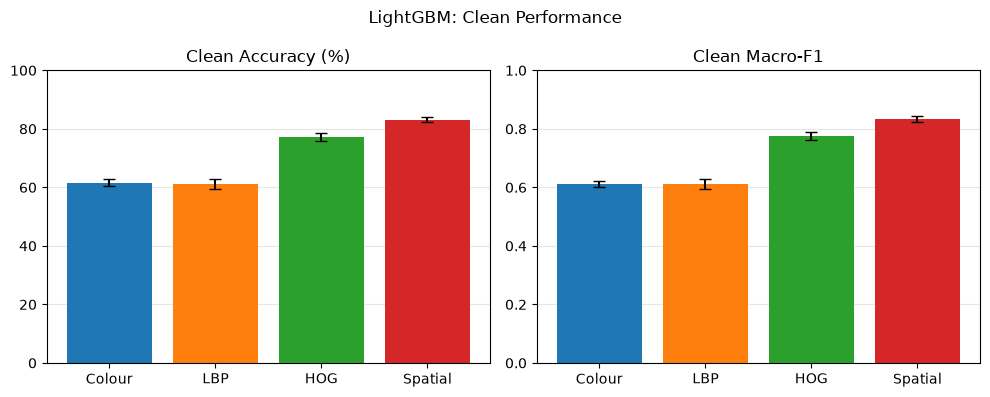

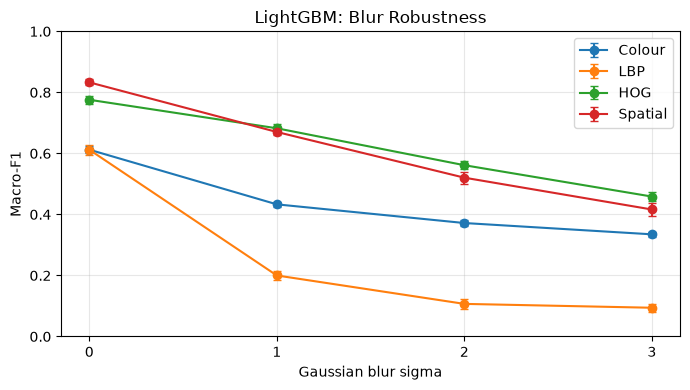

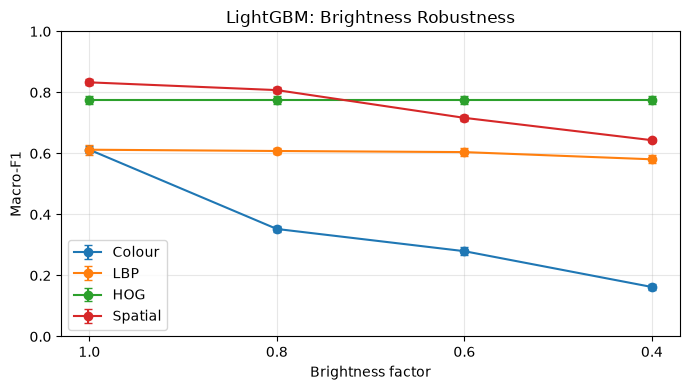

Saved 3 figures to: /Users/williammei/Projects/SML-Project/results/lightgbm/figures


In [25]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

result_dir = Path("results/lightgbm")
figure_dir = result_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

with (result_dir / "lightgbm_results.csv").open() as f:
    plot_rows = list(csv.DictReader(f))

features = [
    ("colour", "Colour"),
    ("lbp", "LBP"),
    ("hog", "HOG"),
    ("spatial", "Spatial"),
]
colours = ["tab:blue", "tab:orange", "tab:green", "tab:red"]


def plot_metric_summary(feature, condition, metric):
    rows = [
        row for row in plot_rows
        if row["feature_representation"] == feature
        and row["condition"] == condition
    ]
    assert len(rows) == 10
    assert {int(row["outer_fold"]) for row in rows} == set(range(10))

    values = np.array([float(row[metric]) for row in rows])
    return values.mean(), values.std(ddof=1)


# Figure 1: clean performance.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric, title, scale in [
    (axes[0], "accuracy", "Clean Accuracy (%)", 100),
    (axes[1], "macro_f1", "Clean Macro-F1", 1),
]:
    stats = np.array([
        plot_metric_summary(feature, "clean", metric)
        for feature, label in features
    ])

    ax.bar(
        np.arange(4),
        stats[:, 0] * scale,
        yerr=stats[:, 1] * scale,
        color=colours,
        capsize=4,
    )
    ax.set_xticks(np.arange(4), [label for feature, label in features])
    ax.set_title(title)
    ax.set_ylim(0, scale)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("LightGBM: Clean Performance")
fig.tight_layout()
fig.savefig(
    figure_dir / "clean_performance_comparison.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# Figures 2 and 3: robustness under blur and brightness degradation.
plot_specs = [
    (
        ["clean", "blur_mild", "blur_medium", "blur_severe"],
        ["0", "1", "2", "3"],
        "Gaussian blur sigma",
        "LightGBM: Blur Robustness",
        "blur_robustness_macro_f1.png",
    ),
    (
        ["clean", "brightness_mild",
         "brightness_medium", "brightness_severe"],
        ["1.0", "0.8", "0.6", "0.4"],
        "Brightness factor",
        "LightGBM: Brightness Robustness",
        "brightness_robustness_macro_f1.png",
    ),
]

for conditions, tick_labels, xlabel, title, filename in plot_specs:
    fig, ax = plt.subplots(figsize=(7, 4))

    for (feature, label), colour in zip(features, colours):
        stats = np.array([
            plot_metric_summary(feature, condition, "macro_f1")
            for condition in conditions
        ])
        ax.errorbar(
            np.arange(4),
            stats[:, 0],
            yerr=stats[:, 1],
            marker="o",
            capsize=3,
            color=colour,
            label=label,
        )

    ax.set_xticks(np.arange(4), tick_labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / filename, dpi=200, bbox_inches="tight")
    plt.show()

print("Saved 3 figures to:", figure_dir.resolve())

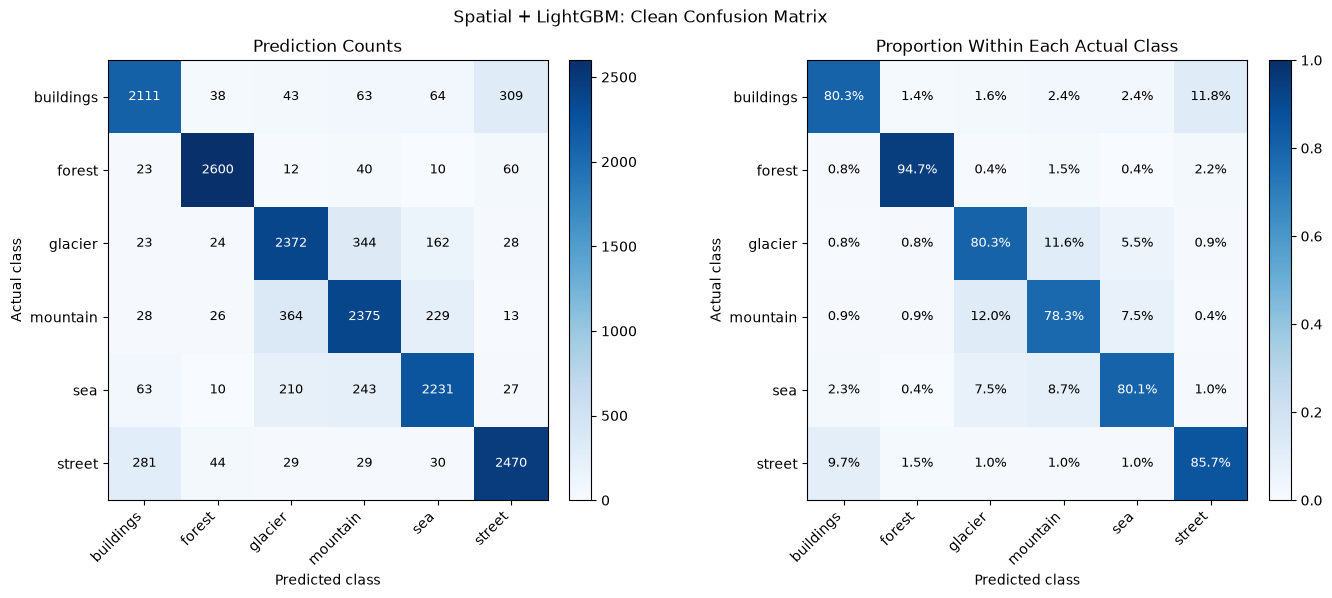

Total test predictions: 17028


In [26]:
import pickle

class_names = [
    "buildings", "forest", "glacier",
    "mountain", "sea", "street",
]

cm_total = np.zeros((6, 6), dtype=np.int64)
test_indices = []

# Combine the ten held-out test folds.
for fold in range(1, 11):
    path = result_dir / "checkpoints" / f"spatial_fold_{fold}.pkl"

    with path.open("rb") as f:
        saved = pickle.load(f)

    predictions = saved["predictions"]
    cm_total += predictions["clean_cm"]
    test_indices.extend(predictions["image_indices"])

assert np.array_equal(
    np.sort(test_indices),
    np.arange(17028),
)
assert cm_total.sum() == 17028

# Normalize each row by its actual class count.
cm_normalized = cm_total / cm_total.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, title, normalized in [
    (axes[0], cm_total, "Prediction Counts", False),
    (axes[1], cm_normalized, "Proportion Within Each Actual Class", True),
]:
    upper = 1 if normalized else cm_total.max()
    im = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=upper)

    ax.set_xticks(range(6), class_names, rotation=45, ha="right")
    ax.set_yticks(range(6), class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(title)

    for row in range(6):
        for column in range(6):
            value = matrix[row, column]
            label = f"{value:.1%}" if normalized else str(int(value))
            ax.text(
                column, row, label,
                ha="center", va="center",
                color="white" if value > upper / 2 else "black",
                fontsize=9,
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Spatial + LightGBM: Clean Confusion Matrix")
fig.tight_layout()
fig.savefig(
    figure_dir / "spatial_clean_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

with (result_dir / "spatial_clean_confusion_matrix.csv").open(
    "w", newline=""
) as f:
    writer = csv.writer(f)
    writer.writerow(["actual / predicted"] + class_names)
    for name, row in zip(class_names, cm_total):
        writer.writerow([name] + row.tolist())

print("Total test predictions:", cm_total.sum())

## Main findings

- Spatial features achieved the highest mean clean Macro-F1: 0.8328.
- HOG achieved higher mean Macro-F1 than the other representations at each tested blur level.
- HOG performance remained unchanged under the tested brightness reductions.
- LBP was relatively stable under brightness reduction but deteriorated substantially under blur.
- Colour features were sensitive to brightness reduction.

The Spatial clean confusion matrix combines held-out predictions from all ten outer folds. Each image contributes exactly one prediction. Common confusions include glacier versus mountain and buildings versus street.